# **Mestrado em Informática**
## *Aprendizagem Máquina*

# **Pós-Graduação em Data Science and Digital Transformation**

## *Análise de Dados e Aprendizagem Automática*

Mónica Vieira Martins
---------------------

># Tutorial 05 - Árvores de Decisão e Florestas Aleatórias

Um tutorial para treinar modelos de árvore de decisão e florestas aleatórias.



AS Árvores de Decisão lidam bem com:
- dados omissos
- valores não padronizados.

Assim, ao contrário dos tutoriais anteriores, iremos trabalhar com os dados (dataset titanic) sem realizar a sua padronização.


# Dados

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
train=pd.read_csv("datasets/titanic_train.csv")
test=pd.read_csv("datasets/titanic_test.csv")

In [11]:
train.columns

Index(['Pclass', 'Age', 'Fare', 'FamilySize', 'Sex', 'Embarked_1',
       'Embarked_0', 'Survived'],
      dtype='object')

In [13]:
ytrain=train.Survived
ytest=test.Survived
print(ytrain.shape)

(712,)


In [6]:
ytrain.head()

0    0
1    0
2    0
3    0
4    0
Name: Survived, dtype: int64

In [14]:
Xtrain=train.drop(["Survived"], axis=1)
Xtest=test.drop(["Survived"], axis=1)

In [8]:
Xtrain.head()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0
0,3.0,29.745184,15.2458,2.0,0.0,0.0,0.0
1,2.0,31.000000,10.5000,0.0,1.0,0.0,1.0
2,2.0,31.000000,37.0042,2.0,1.0,0.0,0.0
3,3.0,20.000000,4.0125,0.0,1.0,0.0,0.0
4,3.0,21.000000,7.2500,0.0,1.0,0.0,1.0


# Função para Avaliação dos Modelos

In [25]:
#Data frame para registo de performance
performance = pd.DataFrame(columns=['Train Accuracy','Test Accuracy', "Test f1"])

In [23]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, accuracy_score
rotulos=["Não sobreviveu", "Sobreviveu"]

def model_evaluation(acc_train, verdadeiros, previstos,  titulo):
  ''' Função que cria e imprime a
    matriz de confusão de um dados modelo e respetivo relatório de classificação
    preenche o df calssification report
    verdadeitos - rotulos evrdadeiros do conjunto de teste
    previstos - rotulos previstos pelo modelo no conjunto de teste
    acc_train - exatidão do modelo no conjunto de treino, calculada previamente
    titulo - nome do modelo
  '''
  conf_matrix =  confusion_matrix(verdadeiros, previstos,  normalize="true")
  s = sns.heatmap(conf_matrix, annot=True, cmap="Greens",
              xticklabels=rotulos, yticklabels=rotulos)
  s.set(xlabel = "Rótulo Previsto", ylabel="Rótulo Verdadeiro", title=titulo)
  plt.show()
  print(classification_report(verdadeiros, previstos))
  #preencher DF com resumo da performance
  #Avaliar o modelo com a exatidão


  acc_test= accuracy_score(verdadeiros, previstos)
  f1 = f1_score(verdadeiros, previstos, average="macro" )

  performance.loc[titulo,
                  ["Train Accuracy","Test Accuracy", "Test f1"]] =[
                  f"{acc_train:.2f}",
                  f"{acc_test:.2f}",
                  f"{f1:.2f}"]



# Árvore de Decisão

Começamos  por treinar um modelo de árvore de decisão com todos os parâmetros por omissão

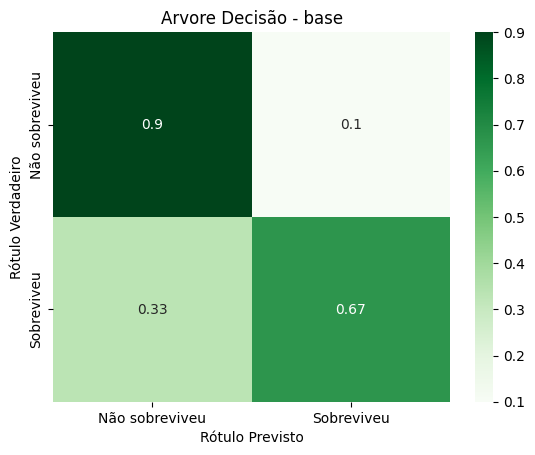

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       110
           1       0.81      0.67      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



,Train Accuracy,Test Accuracy,Test f1
Arvore Decisão - base,0.98,0.81,0.79


Há uma enorme diferença entre a exatidão de treino e de teste, o que indica que o modelo está em *overfitting*.


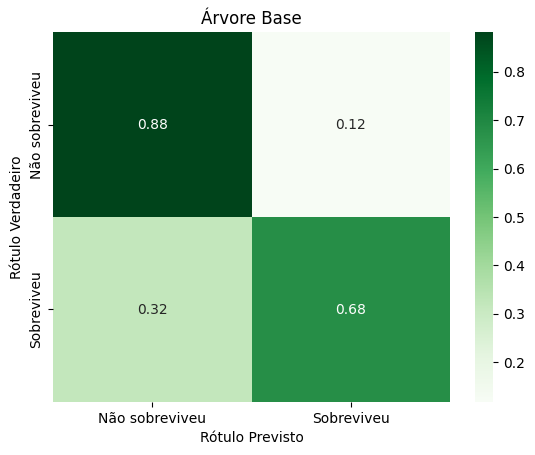

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



,Train Accuracy,Test Accuracy,Test f1
Árvore Base,0.98,0.80,0.79


In [13]:
from sklearn.tree import DecisionTreeClassifier

arvore = DecisionTreeClassifier()
arvore.fit(Xtrain, ytrain)
ypred = arvore.predict(Xtest)
acc_train = arvore.score(Xtrain, ytrain)

model_evaluation(acc_train, ytest, ypred, "Árvore Base")
display(performance)

In [ ]:
#parametros da árvore
arvore.get_params()

#atributos usados para a divisãao seginte
#max-depth none, ramifica ao maximo
#leaf-nodes, none, cria o máximo de folhas (overfit?)

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}


Por omissão:
* A profundidade máxima da árvore: max_depth: int, default=None
* Nª mínimo de amostras para ser considerada uma folha: int or float, default=1



Dada a omplexidade da árvore gerada,  não é estranho que o modelo  esteja em *overfitting*.

## Visualizar a árvore

<Figure size 640x480 with 0 Axes>

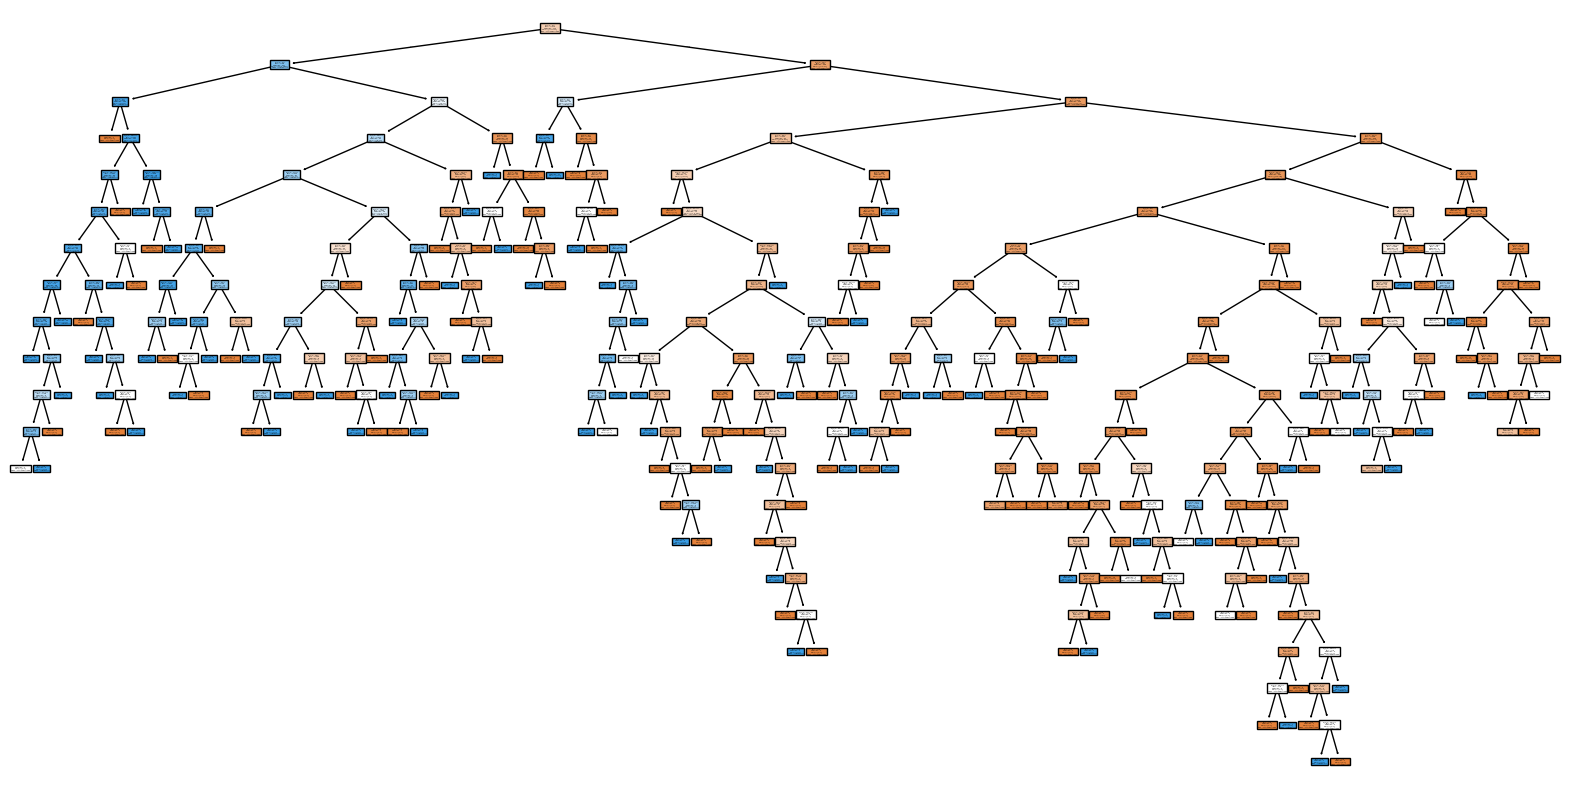

DecisionTreeClassifier()


In [16]:
from sklearn import tree
plt.figure()
plt.figure(figsize=(20,10))
tree.plot_tree(arvore, filled=True, class_names=rotulos)
plt.show()
print(arvore)

# Optimização  de parâmetros com GridSearch

Frequentemente, o valor ótimo de um parâmetro está fortemente dependente do valor de outro(s) parâmetro(s). Por exemplo, nos modelos de SVM para classificação, isso acontece para os valores de C e de gama.

Nessas situações, os parâmetros devem ser optimizados em conjunto.

A biblioteca `scikit learn` disponibiliza algumas funcionalidades para procurar o conjunto de parâmetros que optimiza a performance do modelo.

Uma delas é denominada `GridSearch`, que considera os parâmetros indicados e os respetivos intervalos de valores, testa exaustivamente todas as combinações possíveis e tem como saída a combinação de parâmetros que optimiza a métrica definida.  A funcionalidade `GridSearchCV` tem a característica de utilizar, adicionalmente, um procedimento de validação cruzada.  



Em seguida usa-se a funcionalidade `GridSearchCV` para procurar optimizar os hiperparâmetros do modelo de SVM. Os parâmetros e respetivos valores são indicados sob a forma de um dicionário, sendo os parâmetros as chaves, a que corresponde uma lista de valores possíveis.

Usemos o GridSeach para tentar optimizar os parâmetros do modelo

In [17]:
from sklearn.model_selection import GridSearchCV

max_depth_range = [None,  5, 10, 15]  #valores a testar para profundidade máxima
min_samples_leaf_range = [2, 5, 10] #valores  p/a nº mínimo de amostras para ser
#considerada uma folha
max_leaf_nodes_range = [None, 2, 5, 10, 20]    #Nº maaximo de nodos
min_sample_split_range = [2,5, 10, 20] # nº min amostras necessário para gerar
# um nodo interno

#criar um dicionário com o nome dos parâmetros e os valores a testar
param_grid = {"max_depth": max_depth_range,
              "min_samples_leaf": min_samples_leaf_range,
              "max_leaf_nodes": max_leaf_nodes_range,
              "min_samples_split" : min_sample_split_range
                }

grid = GridSearchCV(estimator=tree.DecisionTreeClassifier(),
                    param_grid=param_grid,
                    cv = 5,
                    scoring='accuracy')

#arvore_opt =grid
grid.fit(Xtrain, ytrain)

print("Exatidao do melhor modelo: %.f" %grid.best_score_)
print(grid.best_params_)

Exatidao do melhor modelo: 1
{'max_depth': 5, 'max_leaf_nodes': 20, 'min_samples_leaf': 2, 'min_samples_split': 2}


Podemos agora usar estes parâmatros para treinar um modelo optimizado

In [18]:
arvore_opt=DecisionTreeClassifier(max_leaf_nodes=20, min_samples_leaf= 2, min_samples_split= 2, max_depth=5 )
arvore_opt.fit(Xtrain, ytrain)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",20
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

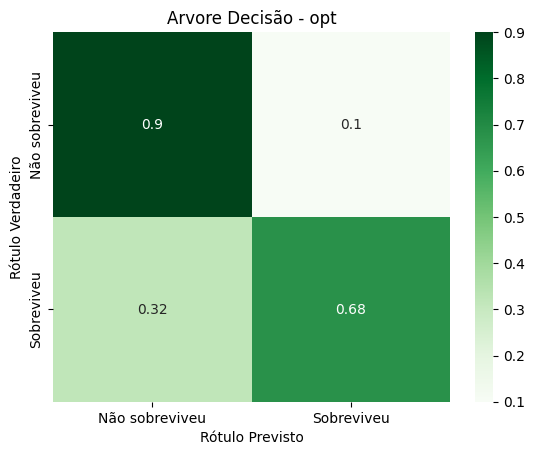

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



In [19]:
ypred=arvore_opt.predict(Xtest)
acc_score = accuracy_score(ytrain, arvore_opt.predict(Xtrain))
model_evaluation(acc_score, ytest, ypred,"Arvore Decisão - opt")



In [ ]:
display(performance)

,Train Accuracy,Test Accuracy,Test f1
Arvore Decisão - base,0.98,0.81,0.79
Arvore Decisão - opt,0.84,0.82,0.80


### Visualização do modelo optimizado

<Figure size 640x480 with 0 Axes>

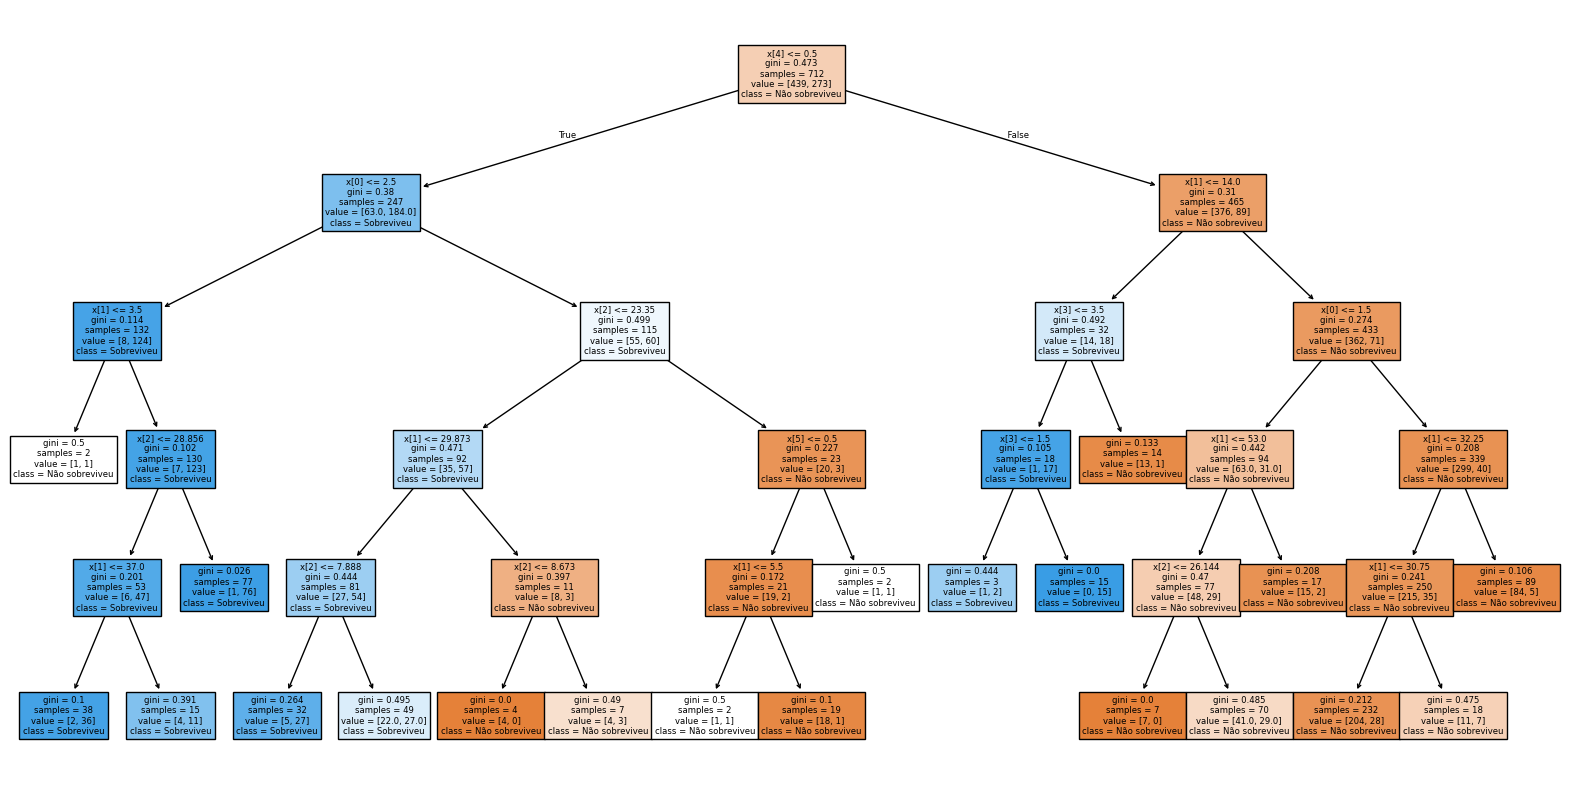

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=20, min_samples_leaf=2)
Index(['Pclass', 'Age', 'Fare', 'FamilySize', 'Sex', 'Embarked_1',
       'Embarked_0'],
      dtype='object')


In [21]:
from sklearn import tree
plt.figure()
plt.figure(figsize=(20,10))
tree.plot_tree(arvore_opt, filled=True, class_names=rotulos)
plt.show()
print(arvore_opt)
print(Xtrain.columns)

# Floresta Aleatória

Treinemos agora um modelo de floresta aleatória com 100 estimadores e os restantes parâmetros com os valores por omissão

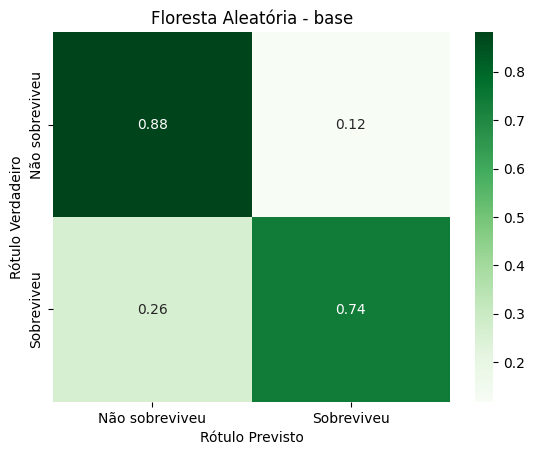

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



,Train Accuracy,Test Accuracy,Test f1
Floresta Aleatória - base,0.98,0.83,0.81
Arvore Decisão - opt,0.84,0.82,0.80
Árvore Base,0.98,0.80,0.79


In [ ]:
from sklearn.ensemble import RandomForestClassifier
floresta = RandomForestClassifier(n_estimators=100)
floresta.fit(Xtrain, ytrain)
ypred=floresta.predict(Xtest)
acc_score = floresta.score(Xtrain, ytrain)
model_evaluation(acc_score, ytest, ypred,"Floresta Aleatória - base")
display(performance.sort_values(by="Test f1", ascending=False))

In [25]:
floresta.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

### Importância dos atributos
Os modelos de florestas aleatórias possuem algum grau de auditabilidade (*explainability*), pois permitem identidicar os atributos que mais influemciam as privisões. Este aspeto é  importante para compreender o comportamento do modelo e de alguma forma garantir alguma transparência nas decisões tomadas.
Em seguida visualiza-se o grau de importância dos atributos no modelo treinado

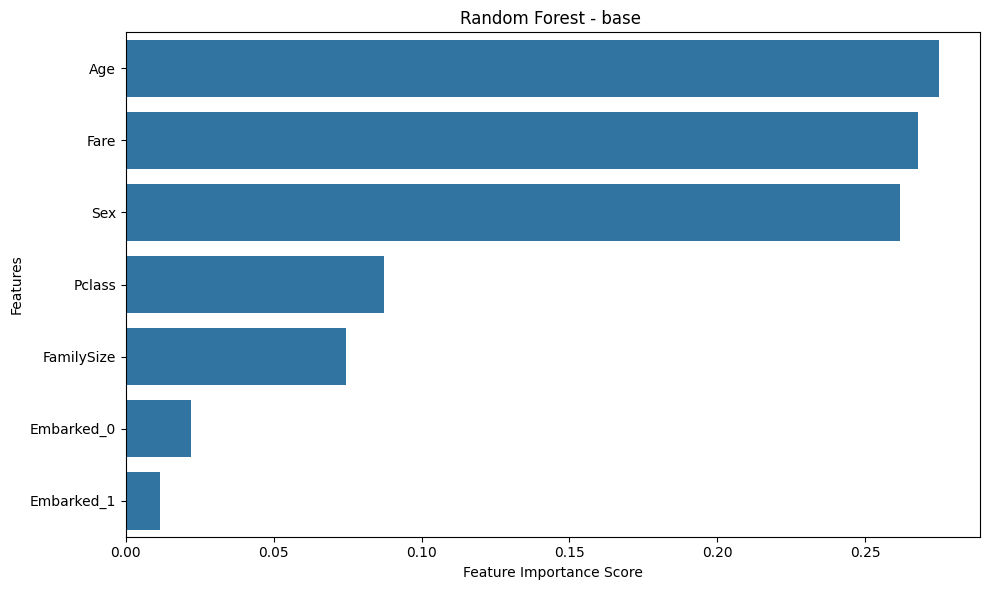

In [27]:
#Determinar a importância dos atributos usados
feature_imp = pd.Series(floresta.feature_importances_, index=Xtrain.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Random Forest - base ")
plt.tight_layout()

### Optimização dos parâmetros com *GridSeachCV*

In [ ]:
# Definir os intervalos de valores para os parâmetros a serem otimizados
n_estimators_range = [50, 100, 200]  # Número de árvores na floresta
max_depth_range = [None, 5, 10, 15]  # Profundidade máxima da árvore
min_samples_split_range = [2, 5, 10]  # Número mínimo de amostras para dividir um nó
min_samples_leaf_range = [1, 2, 4]  # Número mínimo de amostras em uma folha
max_features_range = ['sqrt', 'log2', None]  # Número de recursos a serem considerados ao procurar a melhor divisão

# Criar um dicionário com os parâmetros e os valores a serem testados
param_grid_rf = {
    'n_estimators': n_estimators_range,
    'max_depth': max_depth_range,
    'min_samples_split': min_samples_split_range,
    'min_samples_leaf': min_samples_leaf_range,
    'max_features': max_features_range
}

# Instanciar o GridSearchCV
grid_rf = GridSearchCV(estimator=RandomForestClassifier(),
                       param_grid=param_grid_rf,
                       cv=5,  # Validação cruzada com 5 dobras
                       scoring='accuracy',
                       verbose=1,  # Exibir progresso
                       n_jobs=-1)  # Usar todos os núcleos disponíveis

# Ajustar o modelo aos dados de treino
grid_rf.fit(Xtrain, ytrain)

# Exibir os melhores parâmetros e a exatidão do melhor modelo
print("Exatidão do melhor modelo: %.2f" % grid_rf.best_score_)
print("Melhores parâmetros:", grid_rf.best_params_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


Exatidão do melhor modelo: 0.84
Melhores parâmetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}


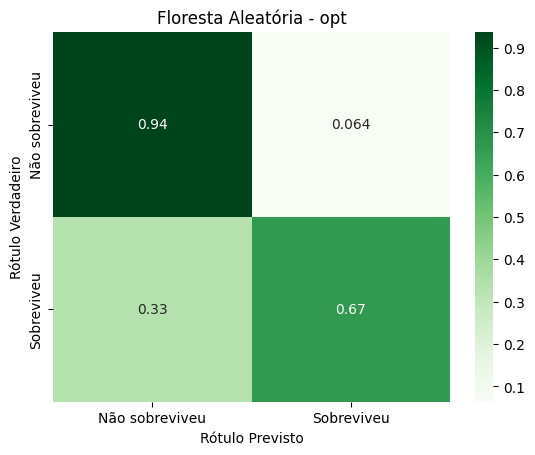

              precision    recall  f1-score   support

           0       0.82      0.94      0.87       110
           1       0.87      0.67      0.75        69

    accuracy                           0.83       179
   macro avg       0.84      0.80      0.81       179
weighted avg       0.84      0.83      0.83       179



,Train Accuracy,Test Accuracy,Test f1
Floresta Aleatória - base,0.98,0.83,0.81
Floresta Aleatória - opt,0.90,0.83,0.81
Arvore Decisão - opt,0.84,0.82,0.80
Árvore Base,0.98,0.80,0.79


In [36]:
# floresta_opt = RandomForestClassifier(max_depth= 15, max_features= 'log2', min_samples_leaf = 4, min_samples_split= 2, n_estimators = 100)
floresta_opt = RandomForestClassifier(**grid_rf.best_params_)
floresta_opt.fit(Xtrain, ytrain)
ypred=floresta_opt.predict(Xtest)
acc_score = accuracy_score(ytrain, floresta_opt.predict(Xtrain))
model_evaluation(acc_score, ytest, ypred,"Floresta Aleatória - opt")
display(performance.sort_values(by="Test f1", ascending=False))

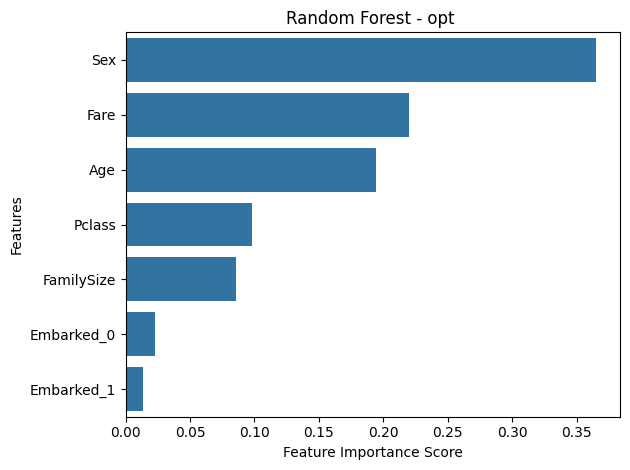

In [37]:
#Determinar a importância dos atributos usados
feature_imp = pd.Series(floresta_opt.feature_importances_, index=Xtrain.columns).sort_values(ascending=False)
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Random Forest - opt ")
plt.tight_layout()


## Exercicio

Os modelos obtidos nesta aula e na naterior tendem a classificar melhor os exemplos da classe dominante.  
Como exercício, aplique técnicas adequadas para lidar com o desequilíbrio entre classes, de forma a obter um desempenho mais equilibrado para ambas.

In [ ]:
!pip install -U scikit-learn imbalanced-learn

In [5]:
# Usar o SMOTE e correr a arvore de novo
from imblearn.over_sampling import SMOTE

In [ ]:

smote = SMOTE(random_state=42)
Xtrain_res, ytrain_res = smote.fit_resample(Xtrain, ytrain)

print("\nDistribuição antes SMOTE:")
print(Xtrain.value_counts())
print("\nDistribuição antes SMOTE (%):")
print((ytrain.value_counts(normalize=True) * 100).round(2))


print("\nDistribuição após SMOTE:")
print(Xtrain_res.value_counts())
print("\nDistribuição após SMOTE (%):")
print((ytrain_res.value_counts(normalize=True) * 100).round(2))


Distribuição antes SMOTE:
Pclass  Age        Fare     FamilySize  Sex  Embarked_1  Embarked_0
3.0     29.745184  7.8958   0.0         1.0  0.0         1.0           10
                   8.0500   0.0         1.0  0.0         1.0            9
                   7.7500   0.0         1.0  1.0         0.0            9
                                        0.0  1.0         0.0            7
2.0     29.745184  0.0000   0.0         1.0  0.0         1.0            5
                                                                       ..
        25.000000  30.0000  2.0         0.0  0.0         1.0            1
                   41.5792  3.0         1.0  0.0         0.0            1
        27.000000  10.5000  0.0         0.0  0.0         1.0            1
                   13.8583  1.0         0.0  0.0         0.0            1
        23.000000  15.0458  0.0         1.0  0.0         0.0            1
Name: count, Length: 620, dtype: int64

Distribuição antes SMOTE (%):
Survived
0    61.66
1

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Definir os intervalos de valores para os parâmetros a serem otimizados
n_estimators_range = [50, 100, 200]  # Número de árvores na floresta
max_depth_range = [None, 5, 10, 15]  # Profundidade máxima da árvore
min_samples_split_range = [2, 5, 10]  # Número mínimo de amostras para dividir um nó
min_samples_leaf_range = [1, 2, 4]  # Número mínimo de amostras em uma folha
max_features_range = ['sqrt', 'log2', None]  # Número de recursos a serem considerados ao procurar a melhor divisão

# Criar um dicionário com os parâmetros e os valores a serem testados
param_grid_rf = {
    'n_estimators': n_estimators_range,
    'max_depth': max_depth_range,
    'min_samples_split': min_samples_split_range,
    'min_samples_leaf': min_samples_leaf_range,
    'max_features': max_features_range
}

# Instanciar o GridSearchCV
grid_rf = GridSearchCV(estimator=RandomForestClassifier(),
                       param_grid=param_grid_rf,
                       cv=5,  # Validação cruzada com 5 dobras
                       scoring='accuracy',
                       verbose=1,  # Exibir progresso
                       n_jobs=-1)  # Usar todos os núcleos disponíveis

# Ajustar o modelo aos dados de treino
grid_rf.fit(Xtrain_res, ytrain_res)

# Exibir os melhores parâmetros e a exatidão do melhor modelo
print("Exatidão do melhor modelo: %.2f" % grid_rf.best_score_)
print("Melhores parâmetros:", grid_rf.best_params_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


Exatidão do melhor modelo: 0.85
Melhores parâmetros: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}


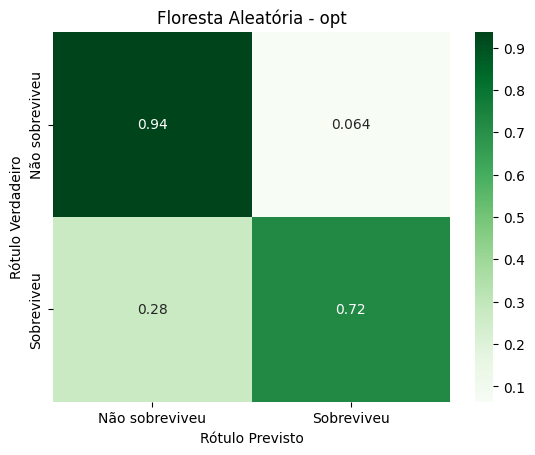

              precision    recall  f1-score   support

           0       0.84      0.94      0.89       110
           1       0.88      0.72      0.79        69

    accuracy                           0.85       179
   macro avg       0.86      0.83      0.84       179
weighted avg       0.86      0.85      0.85       179



,Train Accuracy,Test Accuracy,Test f1
Floresta Aleatória - opt,0.92,0.85,0.84


In [26]:
# floresta_opt = RandomForestClassifier(max_depth= 15, max_features= 'log2', min_samples_leaf = 4, min_samples_split= 2, n_estimators = 100)
floresta_opt = RandomForestClassifier(**grid_rf.best_params_)
floresta_opt.fit(Xtrain_res, ytrain_res)
ypred=floresta_opt.predict(Xtest)
acc_score = floresta_opt.score(Xtrain_res, ytrain_res)
model_evaluation(acc_score, ytest, ypred,"Floresta Aleatória - opt")
display(performance.sort_values(by="Test f1", ascending=False))

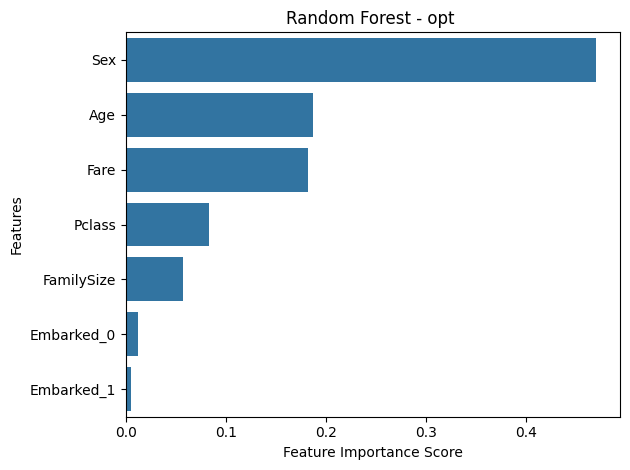

In [27]:
#Determinar a importância dos atributos usados
feature_imp = pd.Series(floresta_opt.feature_importances_, index=Xtrain.columns).sort_values(ascending=False)
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Random Forest - opt ")
plt.tight_layout()